## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from itertools import combinations

# mlxtend — Apriori & association rules
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## 2. Load & Inspect the Dataset

> **Local path:** Update `FILE_PATH` to point to your downloaded CSV from Kaggle.

In [2]:

df = pd.read_csv(r"D:\training\Groceries_dataset.csv\Groceries_dataset.csv")
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(10)

Shape: (38765, 3)
Columns: ['Member_number', 'Date', 'itemDescription']


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [3]:
print('Dataset Info')
print('─' * 40)
print(f'Total transactions (rows) : {df.shape[0]:,}')
print(f'Columns                   : {df.shape[1]}')
print(f'Missing values            : {df.isnull().sum().sum()}')
df.dtypes

Dataset Info
────────────────────────────────────────
Total transactions (rows) : 38,765
Columns                   : 3
Missing values            : 0


Member_number      int64
Date                 str
itemDescription      str
dtype: object

## 3. Data Preprocessing

The raw CSV has one row per **(Member_number, Date, itemDescription)** triplet.  
We group by `Member_number + Date` to reconstruct each shopping basket.

In [4]:
# Rename for convenience
df.columns = ['Member_number', 'Date', 'Item']

# Clean whitespace
df['Item'] = df['Item'].str.strip().str.lower()

# Group into baskets
basket_series = (
    df.groupby(['Member_number', 'Date'])['Item']
      .apply(list)
      .reset_index(drop=True)
)

print(f'Total unique baskets : {len(basket_series):,}')
print(f'Unique items         : {df["Item"].nunique():,}')
print('\nSample baskets:')
basket_series.head(5).apply(lambda x: x)

Total unique baskets : 14,963
Unique items         : 167

Sample baskets:


0    [sausage, whole milk, semi-finished bread, yog...
1                    [whole milk, pastry, salty snack]
2                       [canned beer, misc. beverages]
3                          [sausage, hygiene articles]
4                           [soda, pickled vegetables]
Name: Item, dtype: object

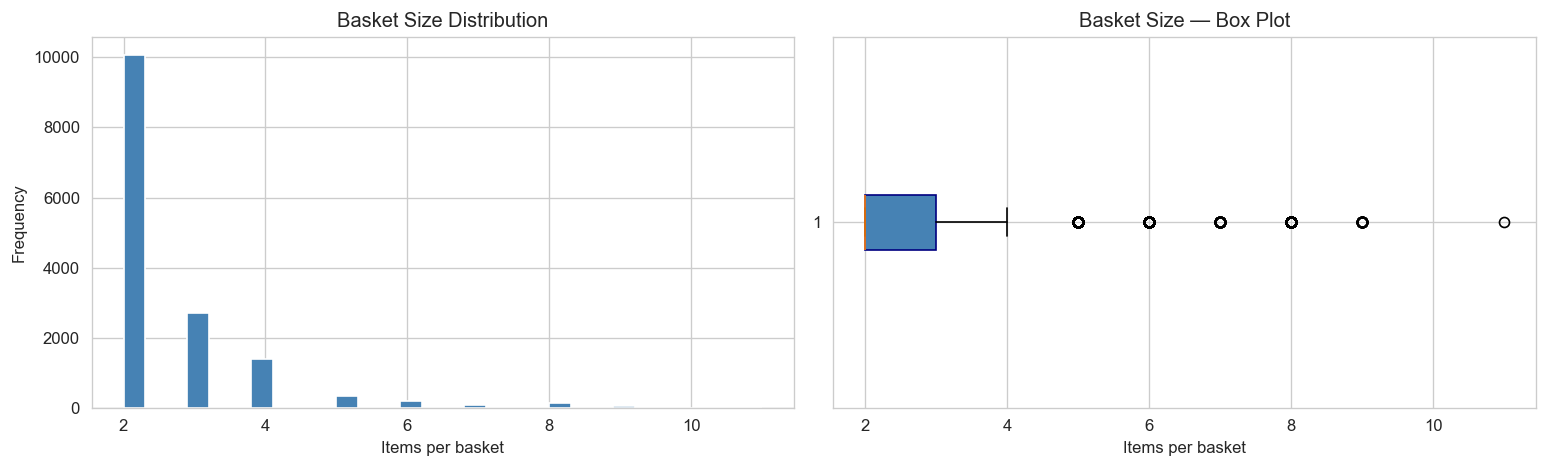

        basket_size
count  14963.000000
mean       2.590724
std        1.117469
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       11.000000


In [5]:
# Basket size distribution
basket_sizes = basket_series.apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(basket_sizes, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Basket Size Distribution')
axes[0].set_xlabel('Items per basket')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(basket_sizes, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Basket Size — Box Plot')
axes[1].set_xlabel('Items per basket')

plt.tight_layout()
plt.show()

print(basket_sizes.describe().rename('basket_size').to_frame())

## 4. Exploratory Data Analysis (EDA)

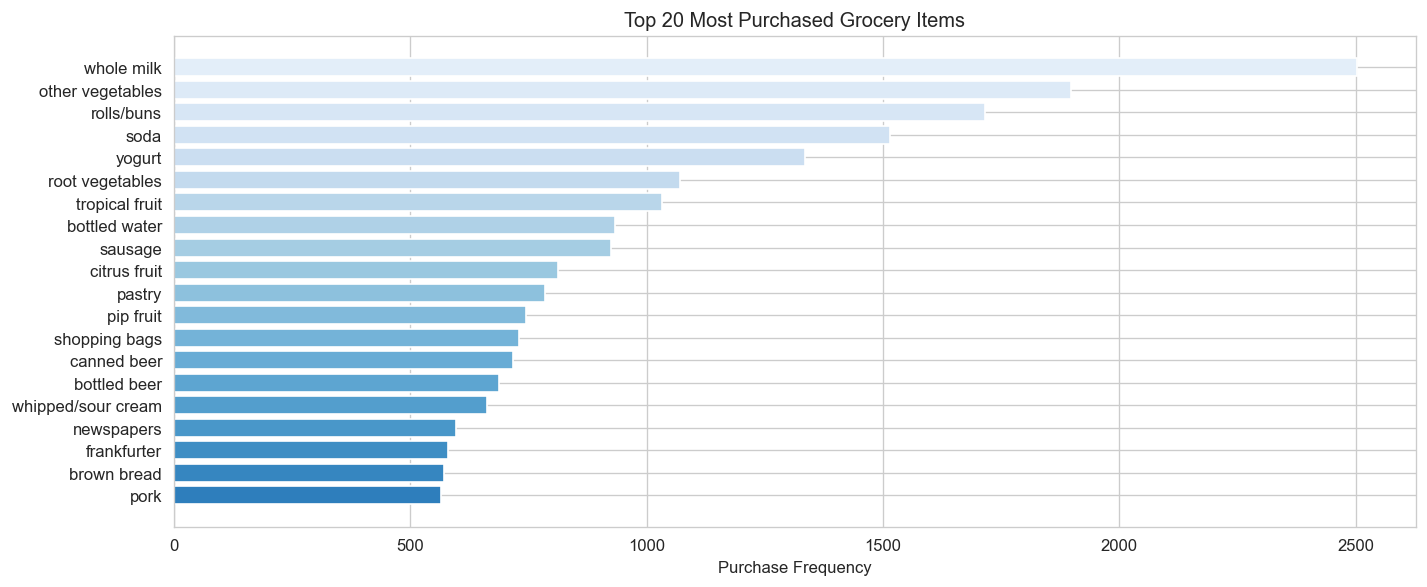

,Item,Count
0,whole milk,2502
1,other vegetables,1898
2,rolls/buns,1716
3,soda,1514
4,yogurt,1334
5,root vegetables,1071
6,tropical fruit,1032
7,bottled water,933
8,sausage,924
9,citrus fruit,812


In [6]:
# Top-20 most purchased items
item_counts = Counter(df['Item']).most_common(20)
items_df = pd.DataFrame(item_counts, columns=['Item', 'Count'])

plt.figure(figsize=(12, 5))
bars = plt.barh(items_df['Item'][::-1], items_df['Count'][::-1],
                color=plt.cm.Blues_r(np.linspace(0.3, 0.9, 20)))
plt.xlabel('Purchase Frequency')
plt.title('Top 20 Most Purchased Grocery Items')
plt.tight_layout()
plt.show()

items_df

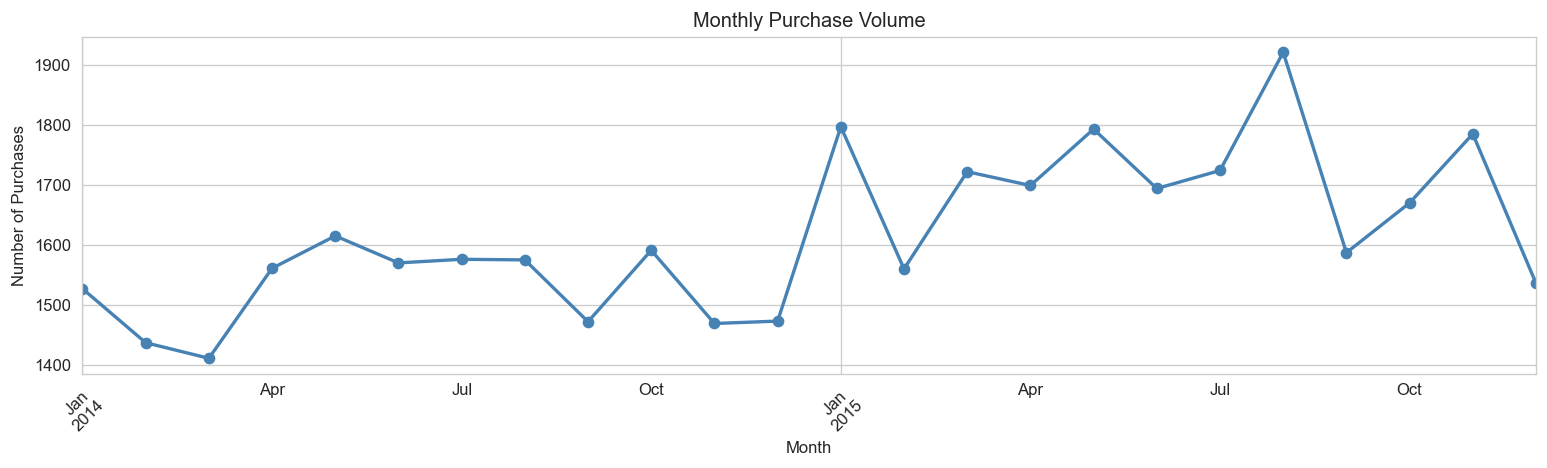

In [7]:
# Purchase trend over time
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
monthly = df.groupby(df['Date'].dt.to_period('M')).size()

plt.figure(figsize=(13, 4))
monthly.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Purchase Volume')
plt.xlabel('Month')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Theory — Association Rules

| Metric | Formula | Meaning |
|---|---|---|
| **Support** | P(A ∪ B) | How often A & B appear together |
| **Confidence** | P(B \| A) = P(A ∪ B) / P(A) | How often the rule is correct |
| **Lift** | Confidence / P(B) | Strength vs. random chance. Lift > 1 = positive association |

### Algorithms
- **Apriori** — BFS level-wise candidate generation; prunes infrequent subsets early (memory-friendly for small datasets).
- **FP-Growth** — Builds a compressed FP-tree; no candidate generation; much faster on large datasets.

## 6. One-Hot Encoding (Transaction Matrix)

In [8]:
te = TransactionEncoder()
te_array = te.fit_transform(basket_series.tolist())
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Transaction matrix shape : {basket_df.shape}')
print(f'Memory usage             : {basket_df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
basket_df.head(3)

Transaction matrix shape : (14963, 167)
Memory usage             : 2.5 MB


,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,...,uht-milk,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 7. Apriori Algorithm

In [9]:
import time

MIN_SUPPORT = 0.01   # items must appear in ≥ 1% of baskets

t0 = time.time()
frequent_itemsets_apriori = apriori(
    basket_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4
)
t1 = time.time()

frequent_itemsets_apriori['length'] = frequent_itemsets_apriori['itemsets'].apply(len)

print(f'Apriori runtime          : {t1-t0:.2f}s')
print(f'Frequent itemsets found  : {len(frequent_itemsets_apriori):,}')
frequent_itemsets_apriori.sort_values('support', ascending=False).head(10)

Apriori runtime          : 0.09s
Frequent itemsets found  : 69


,support,itemsets,length
62,0.157923,frozenset({whole milk}),1
39,0.122101,frozenset({other vegetables}),1
45,0.110005,frozenset({rolls/buns}),1
51,0.097106,frozenset({soda}),1
63,0.085879,frozenset({yogurt}),1
46,0.069572,frozenset({root vegetables}),1
56,0.067767,frozenset({tropical fruit}),1
4,0.060683,frozenset({bottled water}),1
48,0.060349,frozenset({sausage}),1
14,0.053131,frozenset({citrus fruit}),1


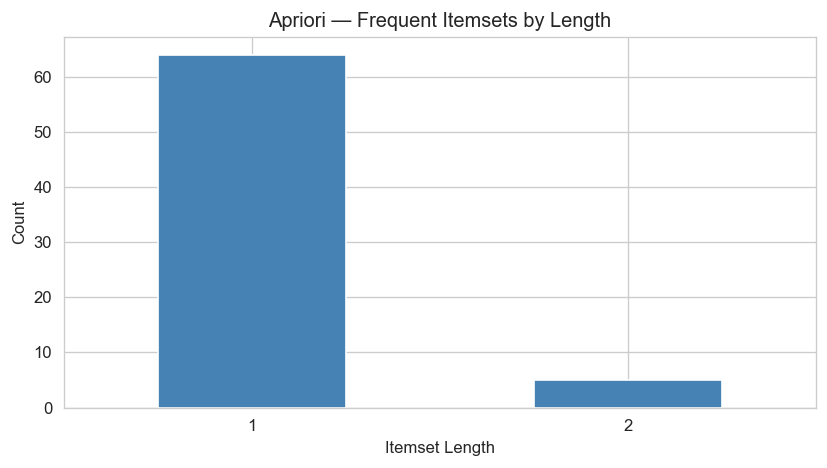

In [10]:
# Itemset length distribution
length_counts = frequent_itemsets_apriori['length'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
length_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Apriori — Frequent Itemsets by Length')
plt.xlabel('Itemset Length')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. FP-Growth Algorithm

In [11]:
t0 = time.time()
frequent_itemsets_fp = fpgrowth(
    basket_df,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4
)
t1 = time.time()

frequent_itemsets_fp['length'] = frequent_itemsets_fp['itemsets'].apply(len)

print(f'FP-Growth runtime        : {t1-t0:.2f}s')
print(f'Frequent itemsets found  : {len(frequent_itemsets_fp):,}')
frequent_itemsets_fp.sort_values('support', ascending=False).head(10)

FP-Growth runtime        : 0.19s
Frequent itemsets found  : 69


,support,itemsets,length
0,0.157923,frozenset({whole milk}),1
15,0.122101,frozenset({other vegetables}),1
11,0.110005,frozenset({rolls/buns}),1
8,0.097106,frozenset({soda}),1
1,0.085879,frozenset({yogurt}),1
22,0.069572,frozenset({root vegetables}),1
18,0.067767,frozenset({tropical fruit}),1
29,0.060683,frozenset({bottled water}),1
2,0.060349,frozenset({sausage}),1
43,0.053131,frozenset({citrus fruit}),1


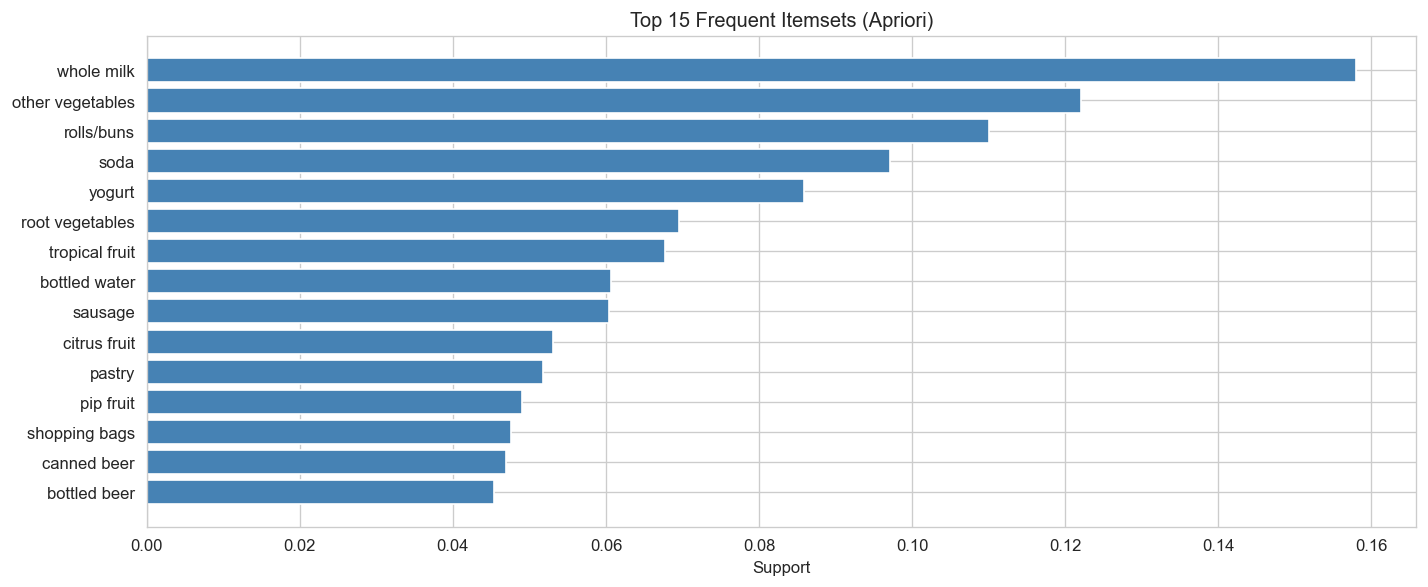

In [12]:
# Side-by-side support comparison (top itemsets)
top_ap = frequent_itemsets_apriori.sort_values('support', ascending=False).head(15)
top_ap['label'] = top_ap['itemsets'].apply(lambda x: ', '.join(sorted(x)))

plt.figure(figsize=(12, 5))
plt.barh(top_ap['label'][::-1], top_ap['support'][::-1], color='steelblue')
plt.xlabel('Support')
plt.title('Top 15 Frequent Itemsets (Apriori)')
plt.tight_layout()
plt.show()

## 9. Generate Association Rules

In [21]:
MIN_CONFIDENCE = 0.05

rules = association_rules(
    frequent_itemsets_fp,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

# Readable labels
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Total rules generated    : {len(rules):,}')
rules[['antecedents_str','consequents_str','support','confidence','lift']].head(15)

Total rules generated    : 10


,antecedents_str,consequents_str,support,confidence,lift
0,whole milk,yogurt,0.011161,0.070673,0.822940
1,yogurt,whole milk,0.011161,0.129961,0.822940
2,rolls/buns,whole milk,0.013968,0.126974,0.804028
3,whole milk,rolls/buns,0.013968,0.088447,0.804028
4,other vegetables,rolls/buns,0.010559,0.086481,0.786154
5,rolls/buns,other vegetables,0.010559,0.095990,0.786154
6,other vegetables,whole milk,0.014837,0.121511,0.769430
7,whole milk,other vegetables,0.014837,0.093948,0.769430
8,whole milk,soda,0.011629,0.073635,0.758296
9,soda,whole milk,0.011629,0.119752,0.758296


## 10. Interpreting Rules — Support, Confidence & Lift

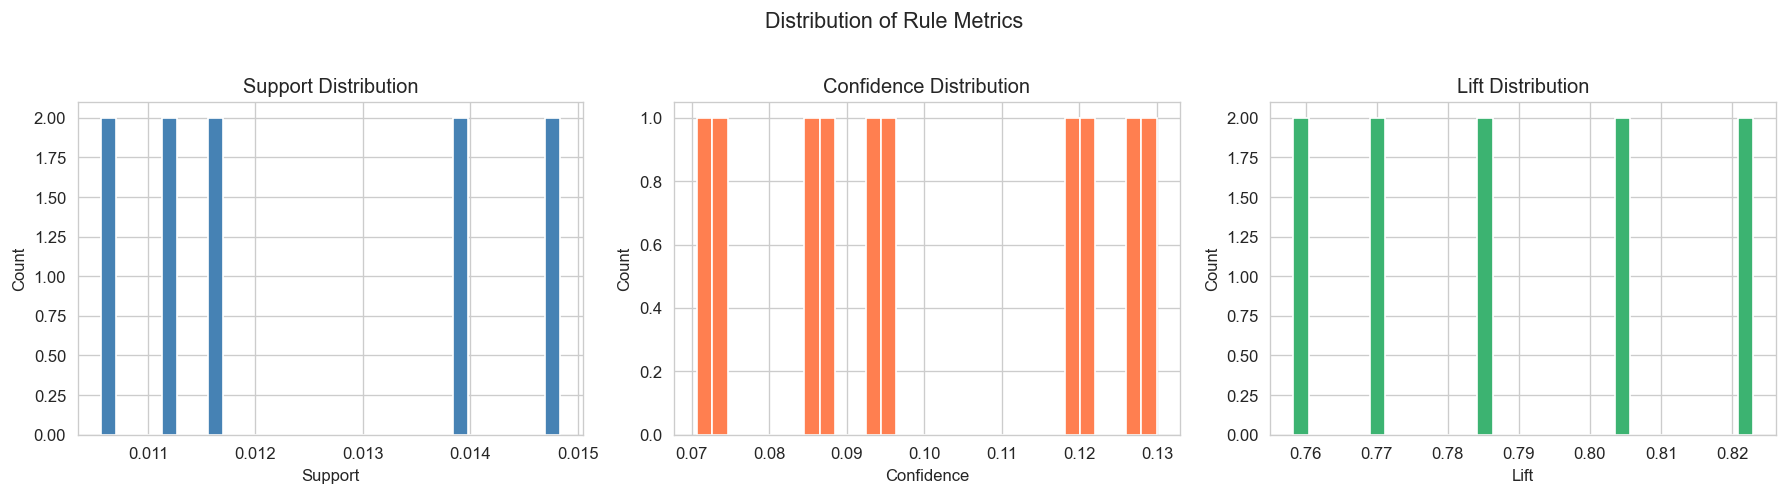

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, title in zip(
    axes,
    ['support', 'confidence', 'lift'],
    ['steelblue', 'coral', 'mediumseagreen'],
    ['Support Distribution', 'Confidence Distribution', 'Lift Distribution']
):
    ax.hist(rules[col], bins=30, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Rule Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

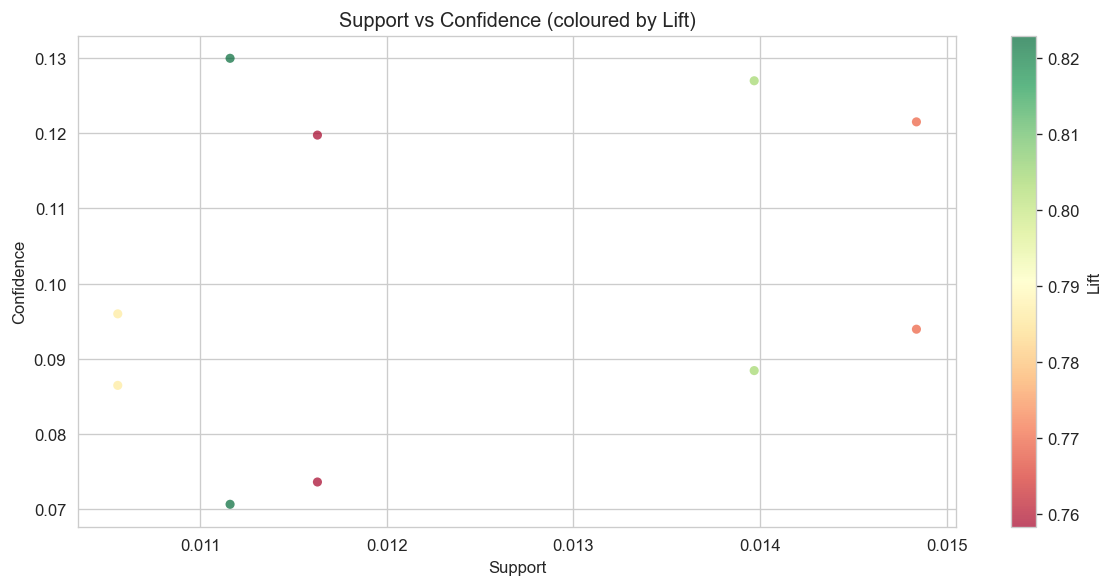

In [23]:
# Scatter: Support vs Confidence, coloured by Lift
plt.figure(figsize=(10, 5))
sc = plt.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', alpha=0.7, s=30, edgecolors='none'
)
cbar = plt.colorbar(sc)
cbar.set_label('Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence (coloured by Lift)')
plt.tight_layout()
plt.show()

In [34]:
# Top rules by lift
print('Top 10 Rules by Lift')
print('=' * 80)
for _, row in rules.head(10).iterrows():
    print(f"  {row['antecedents_str']:35s}  →  {row['consequents_str']:25s}"
          f"  supp={row['support']:.3f}  conf={row['confidence']:.3f}  lift={row['lift']:.2f}")

Top 10 Rules by Lift
  whole milk                           →  yogurt                     supp=0.011  conf=0.071  lift=0.82
  yogurt                               →  whole milk                 supp=0.011  conf=0.130  lift=0.82
  rolls/buns                           →  whole milk                 supp=0.014  conf=0.127  lift=0.80
  whole milk                           →  rolls/buns                 supp=0.014  conf=0.088  lift=0.80
  other vegetables                     →  rolls/buns                 supp=0.011  conf=0.086  lift=0.79
  rolls/buns                           →  other vegetables           supp=0.011  conf=0.096  lift=0.79
  other vegetables                     →  whole milk                 supp=0.015  conf=0.122  lift=0.77
  whole milk                           →  other vegetables           supp=0.015  conf=0.094  lift=0.77
  whole milk                           →  soda                       supp=0.012  conf=0.074  lift=0.76
  soda                                 →  whole milk

## 11. Heatmap — Item Co-occurrence

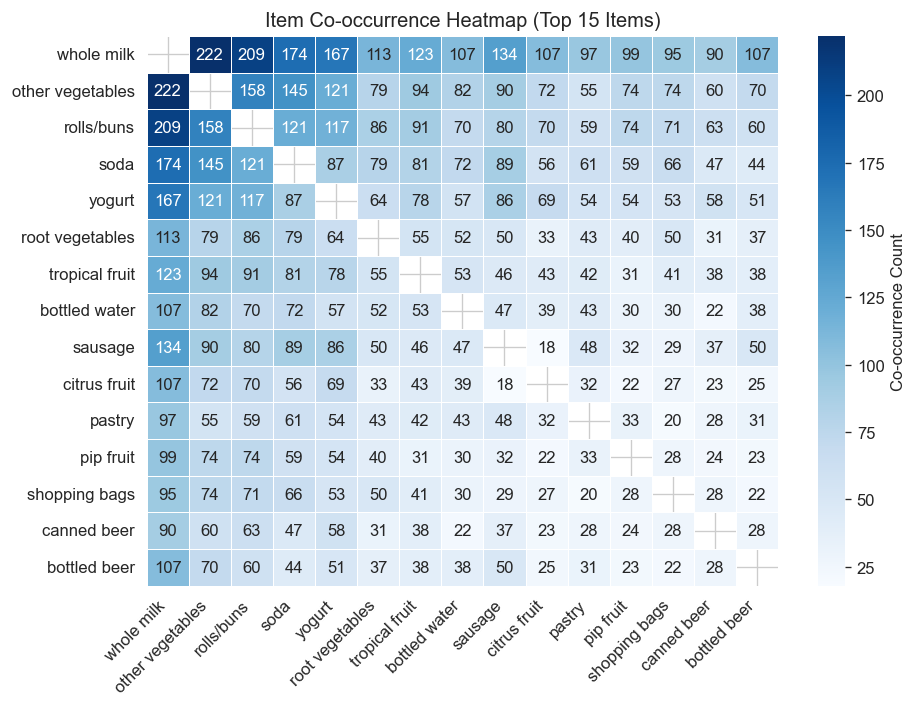

In [33]:
# Build a co-occurrence matrix for the top-15 items
TOP_N = 15
top_items = [item for item, _ in Counter(df['Item']).most_common(TOP_N)]

cooc = pd.DataFrame(0, index=top_items, columns=top_items)
for basket in basket_series:
    basket_top = [i for i in basket if i in top_items]
    for a, b in combinations(set(basket_top), 2):
        cooc.loc[a, b] += 1
        cooc.loc[b, a] += 1

plt.figure(figsize=(8, 6))
mask = np.eye(TOP_N, dtype=bool)
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues',
            mask=mask, linewidths=0.5, cbar_kws={'label': 'Co-occurrence Count'})
plt.title(f'Item Co-occurrence Heatmap (Top {TOP_N} Items)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Network Graph — Top Association Rules

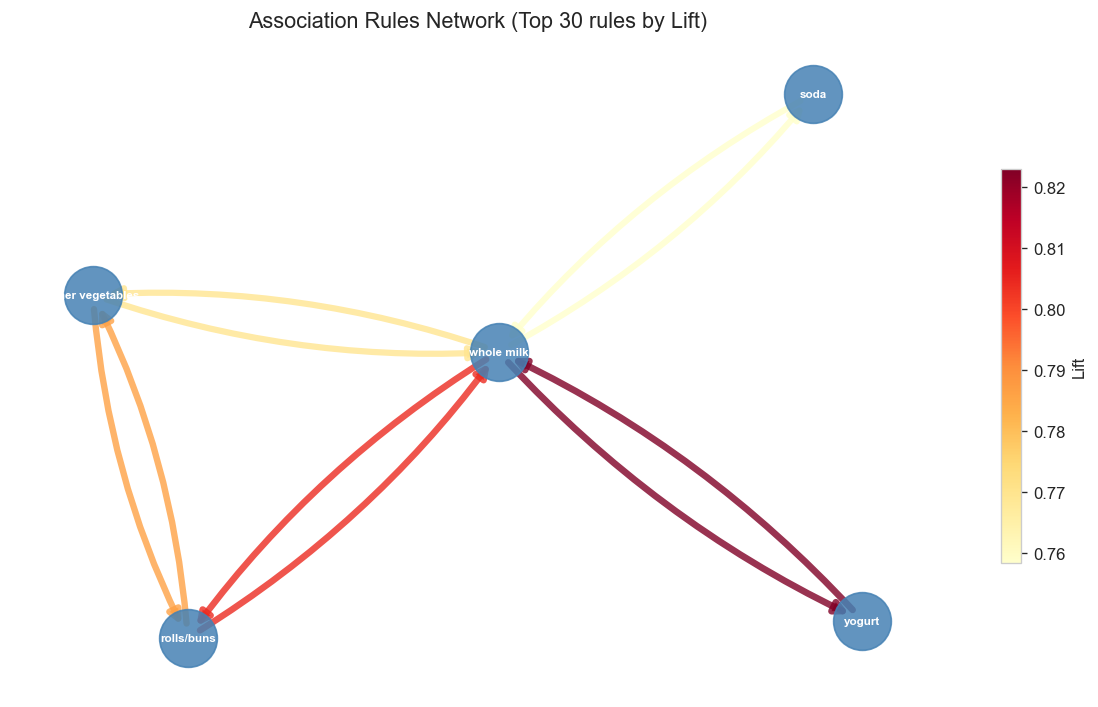

In [32]:
import matplotlib.pyplot as plt
import networkx as nx

TOP_RULES = 30
top_rules = rules.head(TOP_RULES)

G = nx.DiGraph()
for _, row in top_rules.iterrows():
    G.add_edge(
        row['antecedents_str'],
        row['consequents_str'],
        weight=row['lift'],
        confidence=row['confidence']
    )

fig, ax = plt.subplots(figsize=(10, 6))

pos = nx.spring_layout(G, seed=42, k=1.8)

edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
edge_widths  = [w / max(edge_weights) * 4 for w in edge_weights]

nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='steelblue', alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_color='white',
                        font_weight='bold', ax=ax)

edges = nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color=edge_weights,
    edge_cmap=plt.cm.YlOrRd,
    alpha=0.8,
    arrows=True,
    arrowsize=15,
    connectionstyle='arc3,rad=0.1',
    ax=ax
)

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.YlOrRd,
    norm=plt.Normalize(min(edge_weights), max(edge_weights))
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, label='Lift', shrink=0.6)

ax.set_title(f'Association Rules Network (Top {TOP_RULES} rules by Lift)', fontsize=13)
ax.axis('off')

plt.tight_layout()
plt.show()

## 13. Filtering Rules — High-Confidence & High-Lift

In [28]:
strong_rules = rules[(rules['confidence'] >= 0.5) & (rules['lift'] >= 2.0)]
print(f'Strong rules (conf ≥ 0.5, lift ≥ 2.0) : {len(strong_rules)}')
strong_rules[['antecedents_str','consequents_str','support','confidence','lift']].head(20)

Strong rules (conf ≥ 0.5, lift ≥ 2.0) : 0


,antecedents_str,consequents_str,support,confidence,lift


In [29]:
# Leverage & Conviction (bonus metrics)
print('Leverage  = P(A∩B) − P(A)·P(B)  — how much more frequent than chance')
print('Conviction = (1 − P(B)) / (1 − Confidence) — how much rule relies on association')

rules[['antecedents_str','consequents_str','leverage','conviction']].head(10)

Leverage  = P(A∩B) − P(A)·P(B)  — how much more frequent than chance
Conviction = (1 − P(B)) / (1 − Confidence) — how much rule relies on association


,antecedents_str,consequents_str,leverage,conviction
0,whole milk,yogurt,-0.002401,0.983638
1,yogurt,whole milk,-0.002401,0.967861
2,rolls/buns,whole milk,-0.003404,0.964550
3,whole milk,rolls/buns,-0.003404,0.976350
4,other vegetables,rolls/buns,-0.002872,0.974249
5,rolls/buns,other vegetables,-0.002872,0.971117
6,other vegetables,whole milk,-0.004446,0.958551
7,whole milk,other vegetables,-0.004446,0.968928
8,whole milk,soda,-0.003707,0.974663
9,soda,whole milk,-0.003707,0.956636


## 14. Apriori vs FP-Growth — Side-by-Side Comparison

           Frequent Itemsets Found  Runtime (s)
Apriori                       69.0     0.086584
FP-Growth                     69.0     0.140406


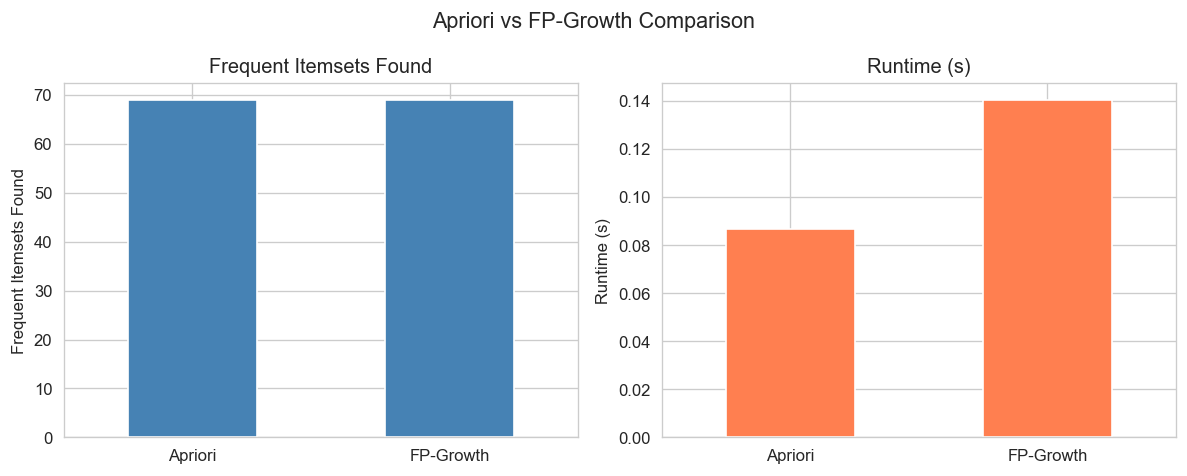

In [30]:
import time

results = {}
for algo_name, algo_fn in [('Apriori', apriori), ('FP-Growth', fpgrowth)]:
    t0 = time.time()
    fi = algo_fn(basket_df, min_support=MIN_SUPPORT, use_colnames=True, max_len=3)
    elapsed = time.time() - t0
    results[algo_name] = {'itemsets': len(fi), 'time': elapsed}

comp_df = pd.DataFrame(results).T
comp_df.columns = ['Frequent Itemsets Found', 'Runtime (s)']
print(comp_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, color in zip(axes,
                           ['Frequent Itemsets Found', 'Runtime (s)'],
                           ['steelblue', 'coral']):
    comp_df[col].astype(float).plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(col)
    ax.set_xticklabels(['Apriori', 'FP-Growth'], rotation=0)
    ax.set_ylabel(col)

plt.suptitle('Apriori vs FP-Growth Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 15. Business Insights & Recommendations

Based on the mined rules, the following actions can be recommended to a grocery retailer:

In [36]:
print('Market Basket Analysis — Business Insights')
print('=' * 60)

print('\n Most Frequently Bought Items (store endcap / visibility):')
for item, count in Counter(df['Item']).most_common(5):
    print(f'   • {item.title():30s}  ({count:,} purchases)')

print('\n Strongest Product Associations (bundle / cross-sell):')
for _, row in rules.head(5).iterrows():
    print(f'   • If [{row["antecedents_str"]}]  →  [{row["consequents_str"]}]')
    print(f'     Conf={row["confidence"]:.2f}, Lift={row["lift"]:.2f}')


Market Basket Analysis — Business Insights

 Most Frequently Bought Items (store endcap / visibility):
   • Whole Milk                      (2,502 purchases)
   • Other Vegetables                (1,898 purchases)
   • Rolls/Buns                      (1,716 purchases)
   • Soda                            (1,514 purchases)
   • Yogurt                          (1,334 purchases)

 Strongest Product Associations (bundle / cross-sell):
   • If [whole milk]  →  [yogurt]
     Conf=0.07, Lift=0.82
   • If [yogurt]  →  [whole milk]
     Conf=0.13, Lift=0.82
   • If [rolls/buns]  →  [whole milk]
     Conf=0.13, Lift=0.80
   • If [whole milk]  →  [rolls/buns]
     Conf=0.09, Lift=0.80
   • If [other vegetables]  →  [rolls/buns]
     Conf=0.09, Lift=0.79
